In [4]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import os # عشان تتعمل مع الفايلز
import re # تدور في نصوص استخدام pastterns
import shutil
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.common.by import By # لتحديد طريقة البحث عن العناصر في الصفحة، زي id أو class أو xpath.
from selenium.webdriver.chrome.options import Options
from webdriver_manager.chrome import ChromeDriverManager
import pandas as pd
import time
import csv
import pycountry # يعرف يقراء اختصار اسامي الدول
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.image as mpimg # بيقراء الصور
import plotly.express as px # سعمل رسومات سهله و جميله
from io import StringIO # يحول الكلام لي ملف مؤقت
from mpl_toolkits.mplot3d import Axes3D # 3D
import seaborn as sns
import plotly.graph_objects as go


In [ ]:

# PART 1: COVID DATA

def get_covid_data():
    url = "https://www.worldometers.info/coronavirus/"
     
    try:  #عشان لو حصل غلط الكود ما يقعش مرة واحدة 
        response = requests.get(url, headers=headers, timeout=15)
        print("COVID status code:", response.status_code)

        if response.status_code != 200:
            print("Could not access COVID website")
            return pd.DataFrame(columns=["Country", "Cases", "Deaths", "Recovered", "Disease"])

        soup = BeautifulSoup(response.text, "html.parser") #هنا بنحوّل الصفحة إلى شكل نقدر نفتش فيه عن العناصر والجداول

        table = soup.find("table", id="main_table_countries_today") #بيدوّر على الجدول الرئيسي اللي فيه بيانات الدول في الصفحة
        if table is None:
            print("COVID table not found")
            return pd.DataFrame(columns=["Country", "Cases", "Deaths", "Recovered", "Disease"])

        tbody = table.find("tbody")
        if tbody is None:
            print("COVID table body not found")
            return pd.DataFrame(columns=["Country", "Cases", "Deaths", "Recovered", "Disease"])

        rows = tbody.find_all("tr")
        data = []

        for row in rows:
            cols = row.find_all("td")
            if len(cols) > 8:
                country = cols[1].get_text(strip=True)    # بيسحب اسم الدول 
                cases = cols[2].get_text(strip=True)  # عدد الحاللات 
                deaths = cols[4].get_text(strip=True) # عدد الوفيات 
                recovered = cols[6].get_text(strip=True) # عدد المتعافين

                if country and country.lower() not in ["world", "total:", ""]:
                    data.append([country, cases, deaths, recovered])

        df = pd.DataFrame(data, columns=["Country", "Cases", "Deaths", "Recovered"])

        for col in ["Cases", "Deaths", "Recovered"]:
            df[col] = (
                df[col]
                .astype(str) # يحولها استرنج 
                .str.replace(",", "", regex=False) # يشيل الفواصل 
                .str.replace("+", "", regex=False) # يشيل العلمات 
                .str.strip() # يشيل المشافات
            )
            df[col] = pd.to_numeric(df[col], errors="coerce") # NANبيحول النصوص إلى أرقام. لو في قيمة غلط، يحولها لـ 

        df["Disease"] = "COVID-19"
        return df

    except Exception as e:
        print("Error while loading COVID data:", e)
        return pd.DataFrame(columns=["Country", "Cases", "Deaths", "Recovered", "Disease"])


# PART 2: WHO DATA

def get_who_data():
    try:
        url = "https://ghoapi.azureedge.net/api/Indicator"
        response = requests.get(url, timeout=20) # بيحدد لينك API الخاص بالمؤشرات.

        if response.status_code != 200:
            print("Could not access WHO indicators")
            return pd.DataFrame()

        indicators = pd.DataFrame(response.json()["value"])

        keywords = [
            "tuberculosis", "malaria", "hiv",
            "diabetes", "influenza", "hepatitis",
            "cancer", "mortality", "incidence"
        ]

        filtered = indicators[   #بيفلتر المؤشرات ويجيب فقط اللي اسمها يحتوي على الكلمات دي.
            indicators["IndicatorName"].str.contains("|".join(keywords), case=False, na=False)
        ]

        codes = filtered["IndicatorCode"].dropna().unique()
        all_data = []

        for code in codes[:20]:
            try:
                url = f"https://ghoapi.azureedge.net/api/{code}"
                response = requests.get(url, timeout=20)

                if response.status_code == 200:
                    data = response.json()["value"]
                    df_temp = pd.DataFrame(data)

                    df_temp = df_temp.loc[:, ~df_temp.columns.duplicated()] #بيشيل الأعمدة المكررة لو موجودة.
                    df_temp["IndicatorCode"] = code
                    df_temp["Disease"] = filtered.loc[  #بيضيف اسم المرض أو المؤشر في عمود Disease
                        filtered["IndicatorCode"] == code,
                        "IndicatorName"
                    ].values[0]

                    all_data.append(df_temp)

            except Exception:
                print("Error in:", code)

            time.sleep(0.5)

        if all_data:
            df_who = pd.concat(all_data, ignore_index=True)
            return df_who
        else:
            print("No WHO data")
            return pd.DataFrame()

    except Exception as e:
        print("Error while loading WHO data:", e)
        return pd.DataFrame()


# PART 3: MERGE DATA

def merge_data(df_covid, df_who):
    
    if not df_who.empty:
        df_who = df_who.rename(columns={
            "SpatialDim": "Country",
            "TimeDim": "Year",
            "NumericValue": "Value"
        })

        df_who = df_who.loc[:, ~df_who.columns.duplicated()]

        needed_cols = ["Country", "Year", "Value", "Disease"]
        df_who = df_who[[c for c in needed_cols if c in df_who.columns]]
        df_who = df_who.dropna(subset=["Country", "Value"]).reset_index(drop=True)
    else:
        df_who = pd.DataFrame(columns=["Country", "Year", "Value", "Disease"])

    
    if not df_covid.empty:
        df_covid["Year"] = 2023  #يضيف سنة ثابتة لبيانات كوفيد.
        df_covid = df_covid.rename(columns={"Cases": "Value"})
        df_covid = df_covid[["Country", "Year", "Value", "Disease"]]
        df_covid = df_covid.dropna().reset_index(drop=True)
    else:
        df_covid = pd.DataFrame(columns=["Country", "Year", "Value", "Disease"])

  
    final_df = pd.concat([df_covid, df_who], ignore_index=True)
    final_df = final_df.drop_duplicates().reset_index(drop=True)

    return final_df #يرجع الجدول النهائي


df_covid = get_covid_data() #يجيب بيانات كوفيد
df_who = get_who_data() #  يجيب بيانات WHO
final_df = merge_data(df_covid, df_who) #يدمجهم في جدول واحد اسمه

columns_needed = ["Country", "Year", "Value", "Disease"]
final_df = final_df[[col for col in columns_needed if col in final_df.columns]]

final_df = final_df.dropna() # يحذف الصفوف اللي فيها حاجات ناقصة
final_df["Value"] = pd.to_numeric(final_df["Value"], errors="coerce") 
final_df = final_df.dropna(subset=["Value"]) #يحذف الصفوف اللي فشل تحويلها لأرقام.
final_df = final_df.sort_values(by=["Disease", "Country", "Year"]).reset_index(drop=True)

final_df.to_csv("final_project_data.csv", index=False)

print(final_df.head())
print("CSV file created successfully!")

Error while loading COVID data: name 'headers' is not defined
  Country    Year  Value                                            Disease
0     NAM  2019.0   88.0  Existence of operational policy/strategy/actio...
1     ALB  2017.0    0.0  Infant mortality rate (deaths per 1000 live bi...
2     PER  2013.0    0.0  Infant mortality rate (deaths per 1000 live bi...
3     PER  2014.0    0.0  Infant mortality rate (deaths per 1000 live bi...
4     PER  2015.0    0.0  Infant mortality rate (deaths per 1000 live bi...
CSV file created successfully!


In [ ]:
# Clean and organize disease data from WHO into structured Excel files per country

df = pd.read_csv("BIG_disease_data.csv")


df = df.rename(columns={
    "SpatialDim": "Country",
    "TimeDim": "Year",
    "NumericValue": "Value"
})


df = df[["Country", "Year", "Value", "Disease"]]


df = df.dropna(subset=["Country", "Disease", "Value"])

df["Year"] = pd.to_numeric(df["Year"], errors="coerce")
df["Value"] = pd.to_numeric(df["Value"], errors="coerce")

df = df.dropna(subset=["Year", "Value"])


df = df[(df["Year"] >= 2020) & (df["Year"] <= 2026)]


df["Year"] = df["Year"].astype(int)

def code_to_country_name(code): # تحويل كود الدولة إلى اسم كامل
    code = str(code).strip() #بتحوّل القيمة لنص وتشيل المسافات الزيادة.

    special_cases = {
        "EGY": "Egypt",
        "CHN": "China",
        "USA": "United States",
        "GBR": "United Kingdom",
        "KOR": "South Korea",
        "PRK": "North Korea",
        "RUS": "Russia",
        "TUR": "Turkey",
        "IRN": "Iran",
        "VEN": "Venezuela",
        "SYR": "Syria"
    }

    if code in special_cases:
        return special_cases[code]

    country = pycountry.countries.get(alpha_3=code) # بيستخدم PYCOUNTRY عشان الدول يبقي اسمها كامل
    if country:
        return country.name #لو لقى الدولة، يرجّع اسمها.

    return code

df["Country"] = df["Country"].apply(code_to_country_name)

# تبسيط اسم المرض
def simplify_disease(name):
    name = str(name).lower()
    if "hiv" in name:
        return "HIV"
    elif "covid" in name:
        return "COVID-19"
    elif "malaria" in name:
        return "Malaria"
    elif "tuberculosis" in name:
        return "Tuberculosis"
    elif "diabetes" in name:
        return "Diabetes"
    elif "influenza" in name:
        return "Influenza"
    elif "hepatitis" in name:
        return "Hepatitis"
    elif "cancer" in name:
        return "Cancer"
    else:
        return "Other"

df["Main_Disease"] = df["Disease"].apply(simplify_disease)

# ترتيب
df = df.sort_values(by=["Country", "Main_Disease", "Year", "Disease"]).reset_index(drop=True)

# حفظ Excel لكل بلد
output_folder = "Countries_2020_2026"
os.makedirs(output_folder, exist_ok=True) #لو موجود أصلًا، ما يطلعش Error

def clean_filename(name):
    return re.sub(r'[\\/*?:"<>|]', "_", str(name).strip()) #دي function تنظف اسم الملف

for country in df["Country"].unique(): #بيلف على كل دولة موجودة مرة واحدة.
    country_df = df[df["Country"] == country].copy()

    if country_df.empty:
        continue

    data_df = country_df[["Country", "Year", "Main_Disease", "Disease", "Value"]]

    summary_df = (
        country_df.groupby("Main_Disease")
        .agg(
            Records_Count=("Value", "count"),
            Average_Value=("Value", "mean"),
            Min_Value=("Value", "min"),
            Max_Value=("Value", "max"),
            Latest_Year=("Year", "max")
        )
        .reset_index()
        .sort_values(by="Records_Count", ascending=False) #ويرتب الأمراض من الأكثر تسجيلًا للأقل
    )

    summary_df["Average_Value"] = summary_df["Average_Value"].round(2)

    file_path = os.path.join(output_folder, clean_filename(country) + ".xlsx")

    with pd.ExcelWriter(file_path, engine="openpyxl") as writer:
        data_df.to_excel(writer, sheet_name="Data", index=False)
        summary_df.to_excel(writer, sheet_name="Summary", index=False)

print("\nDONE - Full country names are ready!")


DONE - Full country names are ready!


In [ ]:
# Fetch and clean disease data from WHO API to build a dataset for analysis.

url = "https://ghoapi.azureedge.net/api/Indicator"
response = requests.get(url)
indicators = pd.DataFrame(response.json()["value"]) #وبعدين يضيف عمود اسمه Disease فيه اسم المرض أو المؤشر

keywords = [
    "hiv", "malaria", "tuberculosis",
    "cancer", "diabetes",
    "hepatitis", "influenza",
    "covid"
]

filtered = indicators[
    indicators["IndicatorName"].str.contains("|".join(keywords), case=False, na=False)
]

print("Indicators found:", len(filtered))

codes = filtered["IndicatorCode"].dropna().unique()

codes = codes[:200]

all_data = []
 
for i, code in enumerate(codes, start=1):  #بيعمل request لكل كود، ويحاول يجيب البيانات الخاصة بيه.
    url = f"https://ghoapi.azureedge.net/api/{code}"
    r = requests.get(url)

    if r.status_code == 200:
        try:
            temp = pd.DataFrame(r.json()["value"])

            if temp.empty:
                continue

            temp["Disease"] = filtered.loc[
                filtered["IndicatorCode"] == code, "IndicatorName"
            ].values[0]

            all_data.append(temp)

        except:
            print("Error:", code)

    time.sleep(0.3)

df = pd.concat(all_data, ignore_index=True)

df = df.rename(columns={
    "SpatialDim": "Country",
    "TimeDim": "Year",
    "NumericValue": "Value"
})


df = df[["Country", "Year", "Value", "Disease"]]

df = df.dropna(subset=["Country", "Value", "Disease"])


df.to_csv("BIG_disease_data_clean.csv", index=False, encoding="utf-8-sig", quoting=csv.QUOTE_ALL)
print("\nSaved BIG_disease_data.csv")


Indicators found: 181

Saved BIG_disease_data.csv


In [5]:
# This code uses Selenium to scrape dynamic COVID-19 data from Worldometer.
chrome_options = Options()
chrome_options.add_argument("--headless")   # يشغل من غير ما يفتح نافذة
chrome_options.add_argument("--disable-dev-shm-usage") #بيقلل مشاكل الذاكرة في البيئات المحدودة


driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()), options=chrome_options)

url = "https://www.worldometers.info/coronavirus/"
driver.get(url)

time.sleep(5)

rows = driver.find_elements(By.CSS_SELECTOR, "#main_table_countries_today tbody tr") # نجيب صفوف الجدول

data = []

for row in rows[:50]:   # أول 50 صف بس للتجربة
    cols = row.find_elements(By.TAG_NAME, "td") #كل صف فيه أعمدة كتير، فبيجيبهم كلهم.
    
    if len(cols) > 8:
        country = cols[1].text.strip()
        total_cases = cols[2].text.strip()
        total_deaths = cols[4].text.strip()
        total_recovered = cols[6].text.strip()
        active_cases = cols[8].text.strip()

        if country:
            data.append([country, total_cases, total_deaths, total_recovered, active_cases])

driver.quit()

df = pd.DataFrame(data, columns=[
    "Country",
    "Total_Cases",
    "Total_Deaths",
    "Total_Recovered",
    "Active_Cases"
])

df.to_csv("selenium_covid_data.csv", index=False)
print("Saved selenium_covid_data.csv")

Saved selenium_covid_data.csv


In [ ]:
# Analyze and organize the Disease Symptoms and Patient Profile dataset into a clean Excel report.

file_name = "Disease_symptom_and_patient_profile_dataset.csv"   # غيريه لو اسم الملف مختلف
df = pd.read_csv("BIG_disease_data.csv")

df.columns = [col.strip().replace(" ", "_") for col in df.columns] #

df = df.drop_duplicates()

for col in df.select_dtypes(include="object").columns: # حذف المسافات الزائدة من الأعمدة النصية
    df[col] = df[col].astype(str).str.strip()


df = df.replace(["", "nan", "None"], pd.NA) # استبدال النصوص الفاضية بـ NaN


def find_column(possible_names, columns): # TRY TO DETECT IMPORTANT COLUMNS
    for name in possible_names:
        for col in columns:
            if name.lower() == col.lower():
                return col
    for name in possible_names:
        for col in columns:
            if name.lower() in col.lower():
                return col
    return None

disease_col = find_column(["Disease", "Diagnosis", "Condition"], df.columns)
symptom_cols = [col for col in df.columns if "symptom" in col.lower()]
age_col = find_column(["Age"], df.columns)
gender_col = find_column(["Gender", "Sex"], df.columns)
outcome_col = find_column(["Outcome", "Result", "Severity"], df.columns)
country_col = find_column(["Country", "Location"], df.columns)


if symptom_cols: # فيها أسماء الأعمدة الخاصة بالأعراض.LIST
    df["All_Symptoms"] = df[symptom_cols].astype(str).apply(
        lambda row: ", ".join([x for x in row if x not in ["<NA>", "nan", "None"]]), #تشيل القيم الفاضية أو الناقصة
        axis=1 #اشتغل على كل صف لوحده
    )
else:
    df["All_Symptoms"] = pd.NA


summary_sheets = {}

if disease_col:
    disease_summary = (
        df[disease_col]
        .value_counts(dropna=False)
        .reset_index()
    )
    disease_summary.columns = ["Disease", "Count"]
    summary_sheets["Disease_Summary"] = disease_summary

if gender_col:
    gender_summary = (
        df[gender_col]
        .value_counts(dropna=False)
        .reset_index()
    )
    gender_summary.columns = ["Gender", "Count"]
    summary_sheets["Gender_Summary"] = gender_summary

if age_col:
    df[age_col] = pd.to_numeric(df[age_col], errors="coerce")
    age_summary = pd.DataFrame({
        "Statistic": ["Count", "Mean", "Min", "Max"],
        "Value": [
            df[age_col].count(),
            round(df[age_col].mean(), 2) if df[age_col].count() > 0 else None,
            df[age_col].min(),
            df[age_col].max()
        ]
    })
    summary_sheets["Age_Summary"] = age_summary

if outcome_col:
    outcome_summary = (
        df[outcome_col]
        .value_counts(dropna=False)
        .reset_index()
    )
    outcome_summary.columns = ["Outcome", "Count"]
    summary_sheets["Outcome_Summary"] = outcome_summary

if disease_col and country_col:
    disease_country_summary = (
        df.groupby([country_col, disease_col])
        .size()
        .reset_index(name="Count")
        .sort_values(by=["Count"], ascending=False)
    )
    summary_sheets["Country_Disease"] = disease_country_summary

clean_file = "clean_disease_symptoms_data.csv"
df.to_csv(clean_file, index=False, encoding="utf-8-sig")



excel_file = "organized_disease_symptoms_report.xlsx"

with pd.ExcelWriter(excel_file, engine="openpyxl") as writer:
    df.to_excel(writer, sheet_name="Clean_Data", index=False)

    for sheet_name, sheet_df in summary_sheets.items():
        safe_sheet_name = sheet_name[:31]
        sheet_df.to_excel(writer, sheet_name=safe_sheet_name, index=False)

# OPTIONAL: ONE FILE PER DISEASE

if disease_col:
    output_folder = "Diseases_Files"
    os.makedirs(output_folder, exist_ok=True)

    def clean_filename(name):
        return re.sub(r'[\\/*?:"<>|]', "_", str(name).strip())

    for disease in df[disease_col].dropna().unique():
        disease_df = df[df[disease_col] == disease].copy()
        file_path = os.path.join(output_folder, clean_filename(disease) + ".xlsx")

        with pd.ExcelWriter(file_path, engine="openpyxl") as writer:
            disease_df.to_excel(writer, sheet_name="Data", index=False)

            summary_rows = []  # ملخص بسيط لكل مرض

            if age_col:                                                         # 2 =  خلي الرقم فيه رقمين بعد العلامة العشرية
                summary_rows.append(["Average Age", round(disease_df[age_col].mean(), 2) if pd.api.types.is_numeric_dtype(disease_df[age_col]) else None])

            if gender_col:                      # mode().iloc = دي بترجع أكثر القيم تكرارًا,خد أول واحدة بس
                top_gender = disease_df[gender_col].mode().iloc[0] if not disease_df[gender_col].mode().empty else None
                summary_rows.append(["Most Common Gender", top_gender])

            if outcome_col:
                top_outcome = disease_df[outcome_col].mode().iloc[0] if not disease_df[outcome_col].mode().empty else None
                summary_rows.append(["Most Common Outcome", top_outcome])

            summary_rows.append(["Records Count", len(disease_df)])

            disease_summary_df = pd.DataFrame(summary_rows, columns=["Metric", "Value"])
            disease_summary_df.to_excel(writer, sheet_name="Summary", index=False)

    

print("\nDONE")


DONE


In [ ]:
# Description for Diseases

df = pd.read_csv("BIG_disease_data.csv")

unique_items = df["Disease"].dropna().unique()

def smart_description(text):
    t = str(text).lower()

    if "hiv" in t:
        return "HIV is a virus that attacks the immune system."
    elif "malaria" in t:
        return "Malaria is a mosquito-borne disease caused by parasites."
    elif "tuberculosis" in t or "tb" in t:
        return "Tuberculosis is a bacterial infection affecting the lungs."
    elif "diabetes" in t:
        return "Diabetes is a chronic disease affecting blood sugar levels."
    elif "hepatitis" in t:
        return "Hepatitis is an inflammation of the liver."
    elif "cancer" in t:
        return "Cancer is uncontrolled growth of abnormal cells."
    elif "influenza" in t:
        return "Influenza is a viral respiratory infection."
    elif "covid" in t:
        return "COVID-19 is a viral respiratory disease."
    
    # مش مرض (indicator أو موضوع)
    elif "prevalence" in t or "rate" in t or "number" in t:
        return "This is a health indicator measuring the spread or frequency of a disease."
    
    elif "air quality" in t:
        return "Air quality refers to the level of pollutants in the air affecting human health."
    
    elif "obesity" in t:
        return "Obesity is a condition of excessive body fat increasing health risks."

    else:
        return "General health-related indicator or condition."

info_df = pd.DataFrame({
    "Item": unique_items
})

info_df["Description"] = info_df["Item"].apply(smart_description)

info_df.to_excel("Full_Health_Descriptions.xlsx", index=False)

print("Saved: Full_Health_Descriptions.xlsx")

Saved: Full_Health_Descriptions.xlsx


In [ ]:
# Scrape COVID-19 country data from Worldometer and save it as a structured CSV file

url = "https://www.worldometers.info/coronavirus/"
headers = {"User-Agent": "Mozilla/5.0"}

response = requests.get(url, headers=headers)
soup = BeautifulSoup(response.text, "html.parser")

table = soup.find("table", id="main_table_countries_today")
rows = table.tbody.find_all("tr")

data = []

for row in rows:
    cols = row.find_all("td")
    if len(cols) > 14:
        country = cols[1].get_text(strip=True)
        total_cases = cols[2].get_text(strip=True)
        total_deaths = cols[4].get_text(strip=True)
        total_recovered = cols[6].get_text(strip=True)
        cases_per_million = cols[9].get_text(strip=True)
        deaths_per_million = cols[10].get_text(strip=True)
        population = cols[14].get_text(strip=True)

        if country and country.lower() not in ["world", "total:"]:
            data.append([
                country,
                total_cases,
                total_deaths,
                total_recovered,
                cases_per_million,
                deaths_per_million,
                population
            ])

df = pd.DataFrame(data, columns=[
    "Country",
    "Total Cases",
    "Total Deaths",
    "Total Recovered",
    "Cases/1M pop",
    "Deaths/1M pop",
    "Population"
])


df.to_csv("worldometer_covid_exact_table.csv", index=False, encoding="utf-8-sig")
print("Saved: worldometer_covid_exact_table.csv")

Saved: worldometer_covid_exact_table.csv


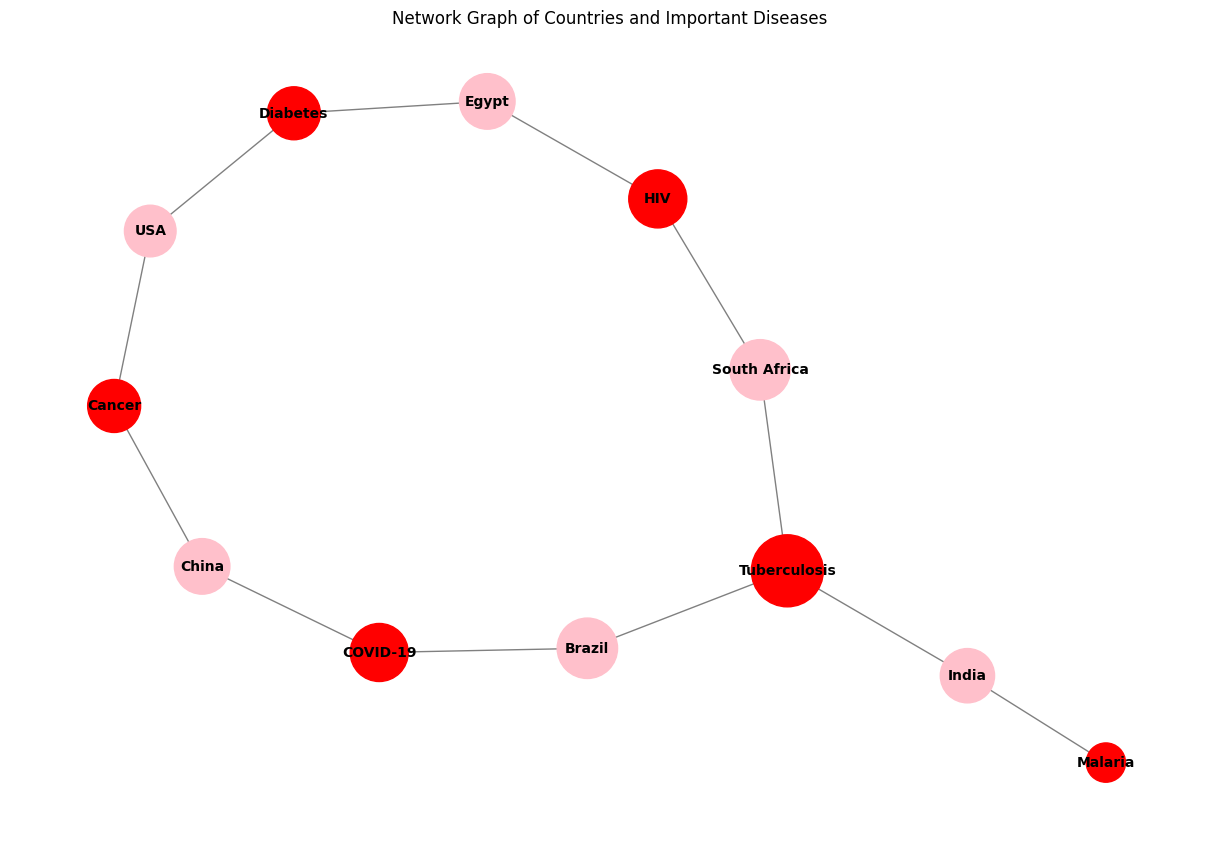

Betweenness Centrality:
Egypt: 0.2000
India: 0.1818
China: 0.2000
USA: 0.1455
Brazil: 0.2727
South Africa: 0.2727
HIV: 0.2364
Malaria: 0.0000
Tuberculosis: 0.4727
Diabetes: 0.1636
Cancer: 0.1636
COVID-19: 0.2364


In [ ]:
# Visualize important diseases globally using a manual NetworkX graph

G = nx.Graph()

countries = ["Egypt", "India", "China", "USA", "Brazil", "South Africa"]
diseases = ["HIV", "Malaria", "Tuberculosis", "Diabetes", "Cancer", "COVID-19"]

edges = [
    ("Egypt", "HIV"),
    ("Egypt", "Diabetes"),
    ("India", "Malaria"),
    ("India", "Tuberculosis"),
    ("China", "COVID-19"),
    ("China", "Cancer"),
    ("USA", "Diabetes"),
    ("USA", "Cancer"),
    ("Brazil", "COVID-19"),
    ("Brazil", "Tuberculosis"),
    ("South Africa", "HIV"),
    ("South Africa", "Tuberculosis")
]

for country in countries:
    G.add_node(country, node_type="Country")

for disease in diseases:
    G.add_node(disease, node_type="Disease")

G.add_edges_from(edges)

betweenness = nx.betweenness_centrality(G)

node_sizes = [4000 * betweenness[node] + 800 for node in G.nodes()]

node_colors = []
for node, attr in G.nodes(data=True):
    if attr["node_type"] == "Country":
        node_colors.append("pink")
    else:
        node_colors.append("red")

plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, seed=42)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=node_sizes,
    node_color=node_colors,
    font_size=10,
    font_weight="bold",
    edge_color="gray"
)

plt.title("Network Graph of Countries and Important Diseases")
plt.axis("off")
plt.show()

print("Betweenness Centrality:")
for node, centrality in betweenness.items():
    print(f"{node}: {centrality:.4f}")

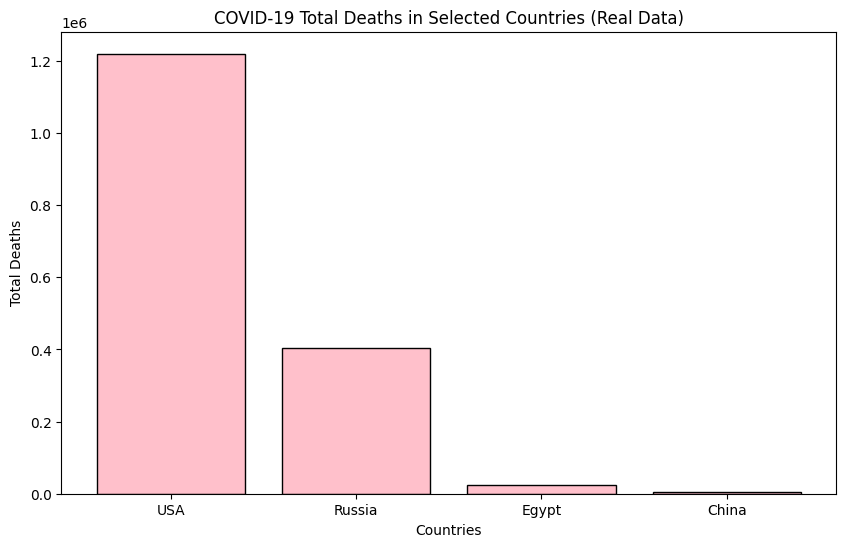

In [ ]:
# Plot real COVID-19 deaths for selected countries

df = pd.read_csv("worldometer_covid_exact_table.csv")

df["Total Deaths"] = (
    df["Total Deaths"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.replace("+", "", regex=False)
    .str.strip()
)

df["Total Deaths"] = pd.to_numeric(df["Total Deaths"], errors="coerce")

countries = ["Egypt", "USA", "China", "Russia"]
selected_df = df[df["Country"].isin(countries)]

plt.figure(figsize=(10, 6))
plt.bar(selected_df["Country"], selected_df["Total Deaths"], color='pink', edgecolor='black')

plt.title("COVID-19 Total Deaths in Selected Countries (Real Data)")
plt.xlabel("Countries")
plt.ylabel("Total Deaths")

plt.show()

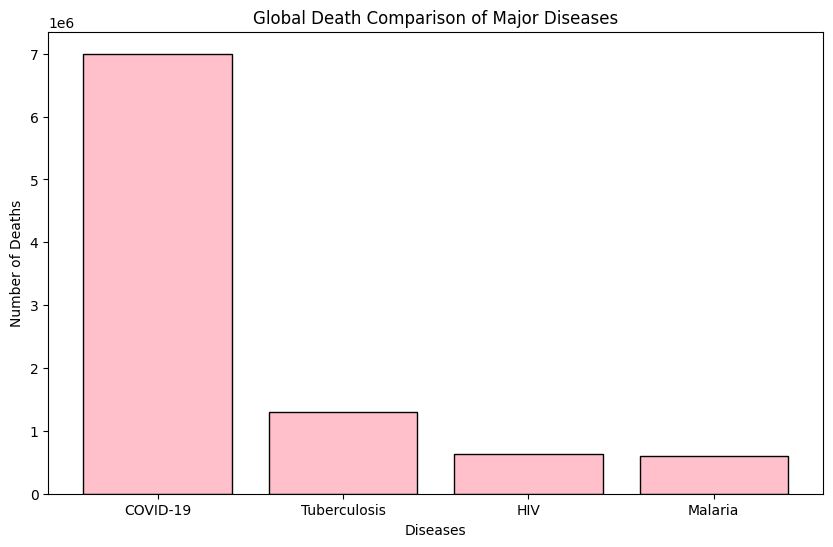

In [29]:
# Compare deaths for 4 major diseases


diseases = ["COVID-19", "Tuberculosis", "HIV", "Malaria"]

# عدد الوفيات (تقريبي عالمي - تقديرات منظمة الصحة العالمية)
deaths = [7000000, 1300000, 630000, 600000]

# الرسم
plt.figure(figsize=(10, 6))
plt.bar(diseases, deaths, color='pink', edgecolor='black')

plt.title("Global Death Comparison of Major Diseases")
plt.xlabel("Diseases")
plt.ylabel("Number of Deaths")

plt.show()

In [6]:
#  Web photo It displays a map of COVID-19 deaths worldwide.

url = "https://raw.githubusercontent.com/owid/covid-19-data/master/public/data/latest/owid-covid-latest.csv"
df = pd.read_csv(url)

filtered_df = df.dropna(subset=["total_deaths"]).copy()
filtered_df = filtered_df[~filtered_df["iso_code"].str.startswith("OWID")] #احذف أي صف الـ iso_code بتاعه يبدأ بـ OWID لأنه مش دولة حقيقية، غالبًا world أو continent أو group.
filtered_df = filtered_df.nlargest(20, "total_deaths")

filtered_df = filtered_df.rename(columns={
    "location": "Country",
    "total_deaths": "Deaths"
})

fig = px.scatter_geo(
    filtered_df,
    locations="iso_code",
    hover_name="Country",
    size="Deaths",
    projection="natural earth",
    title="Top 20 Countries by Total COVID-19 Deaths",
    hover_data={"Deaths": ":,.0f"}
)

fig.update_traces(
    marker=dict(
        color="pink",
        line=dict(color="black", width=1),
        sizemode="area",
        sizeref=filtered_df["Deaths"].max() / 60
    )
)

fig.update_traces(
    marker=dict(
        color="pink",
        sizemode="area",
        sizeref=5000,  # مهم عشان الأحجام متبقاش ضخمة الي هي النقطه البنك يعني
        line=dict(color="black", width=1)
    )
)

fig.show(renderer="browser")

In [9]:
#Heat Mappp for World MAP

data = {
    "Country": ["Egypt", "United States", "China", "Russia", "India", "Brazil"],
    "Lat": [26.8, 37.1, 35.8, 61.5, 20.6, -14.2],
    "Lon": [30.8, -95.7, 104.2, 105.3, 78.9, -51.9],
    "Deaths": [80000, 500000, 100000, 300000, 250000, 120000]
}

df = pd.DataFrame(data)

fig = go.Figure(go.Densitymap(
    lat=df["Lat"],
    lon=df["Lon"],
    z=df["Deaths"],
    radius=30,
    hovertemplate="<b>%{customdata[0]}</b><br>Deaths: %{z}<extra></extra>",
    customdata=df[["Country"]].values
))

fig.update_layout(
    title="World Disease Heatmap by Death Intensity",
    mapbox_style="carto-positron",
    mapbox_zoom=0.8,
    mapbox_center={"lat": 20, "lon": 0},
    margin={"r":0, "t":50, "l":0, "b":0}
)

fig.show()

In [ ]:
# Geographic Bubble Map of Disease Distribution (2021)

data = {
    "Country": [
        "Egypt", "United States", "China", "Russia",
        "India", "Brazil", "South Africa", "Nigeria"
    ],
    
    "Lat": [
        26.8, 37.1, 35.8, 61.5,
        20.6, -14.2, -30.6, 9.1
    ],
    
    "Lon": [
        30.8, -95.7, 104.2, 105.3,
        78.9, -51.9, 22.9, 8.7
    ],
    
    "Disease": [
        "COVID-19", "COVID-19", "Tuberculosis", "COVID-19",
        "Tuberculosis", "HIV/AIDS", "HIV/AIDS", "Malaria"
    ],
    
    
    "Deaths": [ # 2021
        22000,    # Egypt COVID
        450000,   # USA COVID
        35000,    # China TB
        300000,   # Russia COVID
        490000,   # India TB
        14000,    # Brazil HIV
        72000,    # South Africa HIV
        200000    # Nigeria Malaria
    ],
    
    "Year": [2021]*8
}

df = pd.DataFrame(data)

fig = px.scatter_geo(
    df,
    lat="Lat",
    lon="Lon",
    color="Disease",
    size="Deaths",
    hover_name="Country",
    hover_data={
        "Disease": True,
        "Deaths": True,
        "Year": True,
        "Lat": False,
        "Lon": False
    },
    title="World Disease Distribution (2021)",
    projection="natural earth"
)

fig.update_traces(
    marker=dict(line=dict(width=1, color="black"))
)

fig.update_layout(
    title_x=0.5,
    geo=dict(
        showland=True,
        landcolor="rgb(235,235,235)",
        showcountries=True,
        countrycolor="gray",
        showocean=True,
        oceancolor="rgb(210,230,255)"
    )
)

fig.show()

In [4]:
# بيانات تجريبية لكل ولاية
data = {
    "State": ["CA", "TX", "FL", "NY", "IL", "PA", "OH", "GA", "NC", "MI"],
    "Value": [300, 250, 200, 280, 180, 170, 160, 190, 150, 140]
}

df = pd.DataFrame(data)

fig = px.choropleth(
    df,
    locations="State",          # اختصار الولاية
    locationmode="USA-states",  # خريطة ولايات أمريكا
    color="Value",              # القيم اللي هتحدد اللون
    scope="usa",                # نعرض أمريكا فقط
    color_continuous_scale="Oranges",  # تدرج برتقالي
    title="US Choropleth Map (Shades)"
)

fig.show()

In [ ]:
# Choropleth map visualizing obesity rates across U.S. states, highlighting regional health patterns through color intensity."


url = "https://www.cdc.gov/obesity/media/files/2025/11/2-Obesity-by-state-in-2024.csv"


df = pd.read_csv(url)


df.columns = [c.strip() for c in df.columns]
# print("Columns in file:")
# print(df.columns.tolist())


lower_map = {c.lower(): c for c in df.columns}

def find_col(possible_names):
    for p in possible_names:
        for real_col in df.columns:
            if p in real_col.lower():
                return real_col
    return None

state_col = find_col(["state", "location", "geographic"])
value_col = find_col(["prevalence", "percent", "value", "estimate"])

# print("Detected state column:", state_col)
# print("Detected value column:", value_col)


data = df[[state_col, value_col]].copy()
data.columns = ["State", "ObesityRate"]

# نحول النسبة لرقم لو فيها %
data["ObesityRate"] = (
    data["ObesityRate"]
    .astype(str)
    .str.replace("%", "", regex=False)
    .str.strip()
)
data["ObesityRate"] = pd.to_numeric(data["ObesityRate"], errors="coerce")

data = data.dropna(subset=["State", "ObesityRate"])

# لو فيه territories أو DC ومش عايزاهم، سيبي السطر ده
# data = data[~data["State"].isin(["Guam", "Puerto Rico", "Virgin Islands", "District of Columbia"])]

# تحويل أسماء الولايات الكاملة لاختصارات داخلية فقط عشان الخريطة تشتغل
state_to_code = {
    "Alabama": "AL", "Alaska": "AK", "Arizona": "AZ", "Arkansas": "AR",
    "California": "CA", "Colorado": "CO", "Connecticut": "CT", "Delaware": "DE",
    "Florida": "FL", "Georgia": "GA", "Hawaii": "HI", "Idaho": "ID",
    "Illinois": "IL", "Indiana": "IN", "Iowa": "IA", "Kansas": "KS",
    "Kentucky": "KY", "Louisiana": "LA", "Maine": "ME", "Maryland": "MD",
    "Massachusetts": "MA", "Michigan": "MI", "Minnesota": "MN", "Mississippi": "MS",
    "Missouri": "MO", "Montana": "MT", "Nebraska": "NE", "Nevada": "NV",
    "New Hampshire": "NH", "New Jersey": "NJ", "New Mexico": "NM", "New York": "NY",
    "North Carolina": "NC", "North Dakota": "ND", "Ohio": "OH", "Oklahoma": "OK",
    "Oregon": "OR", "Pennsylvania": "PA", "Rhode Island": "RI", "South Carolina": "SC",
    "South Dakota": "SD", "Tennessee": "TN", "Texas": "TX", "Utah": "UT",
    "Vermont": "VT", "Virginia": "VA", "Washington": "WA", "West Virginia": "WV",
    "Wisconsin": "WI", "Wyoming": "WY", "District of Columbia": "DC"
}

data["Code"] = data["State"].map(state_to_code)

data = data.dropna(subset=["Code"])

fig = px.choropleth(
    data_frame=data,
    locations="Code",
    locationmode="USA-states",
    scope="usa",
    color="ObesityRate",
    hover_name="State",
    hover_data={"Code": False, "ObesityRate": ':.1f'},
    color_continuous_scale="RdPu",
    labels={"ObesityRate": "Obesity Rate (%)"},
    title="Adult Obesity Rate by U.S. State (CDC, 2024)"
)

fig.update_layout(
    title_font_size=24,
    geo=dict(
        bgcolor="white",
        lakecolor="white"
    ),
    margin=dict(l=20, r=20, t=60, b=20),
    coloraxis_colorbar=dict(
        title="Rate %",
        tickformat=".1f"
    )
)

fig.show()

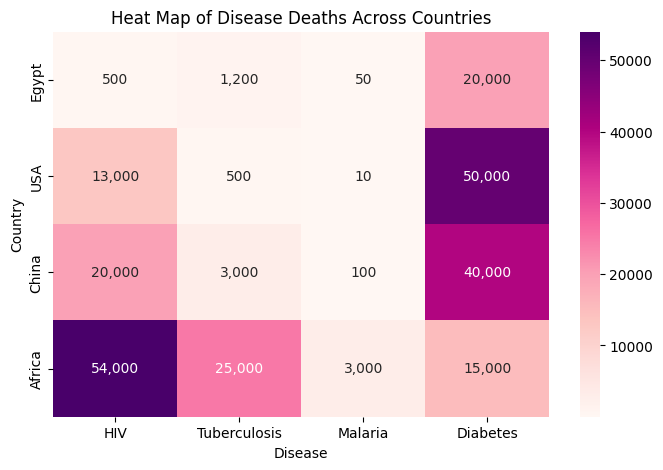

In [ ]:
# Comparing dangerous and less dangerous diseases across different countries

data = {
    "HIV": [500, 13000, 20000, 54000],
    "Tuberculosis": [1200, 500, 3000, 25000],
    "Malaria": [50, 10, 100, 3000],
    "Diabetes": [20000, 50000, 40000, 15000]
}

countries = ["Egypt", "USA", "China", "Africa"]

df = pd.DataFrame(data, index=countries)

plt.figure(figsize=(8,5))
sns.heatmap(df, annot=True, cmap="RdPu", fmt=",.0f")
plt.title("Heat Map of Disease Deaths Across Countries")
plt.xlabel("Disease")
plt.ylabel("Country")
plt.show()

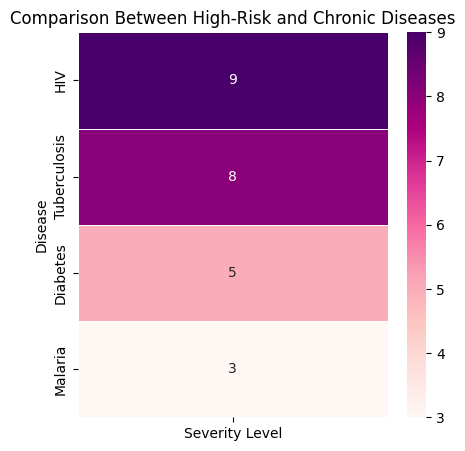

In [ ]:
# Comparison Between High-Risk Diseases and Chronic Diseases Using Survival Rate

data = {
    "Disease": ["HIV", "Tuberculosis", "Heart Disease", "Kidney Disease"],
    "Survival Rate": [65, 78, 85, 80]
}

df = pd.DataFrame(data)
df = df.set_index("Disease")

plt.figure(figsize=(5, 5))
sns.heatmap(df, annot=True, cmap="RdPu", linewidths=0.5)

plt.title("Comparison Between High-Risk and Chronic Diseases")
plt.xlabel("")
plt.ylabel("Disease")
plt.show()

In [4]:
# This map shows the main disease in each selected U.S. state using different colors

df = pd.DataFrame({
    "State": ["California", "Texas", "Florida", "New York", "Ohio", "Nevada"],
    "Code":  ["CA", "TX", "FL", "NY", "OH", "NV"],
    "Diabetes": [90, 85, 20, 25, 70, 15],
    "COVID-19": [30, 20, 95, 35, 25, 80],
    "Tuberculosis": [10, 15, 30, 98, 20, 25]
})

df["Main Disease"] = df[["Diabetes", "COVID-19", "Tuberculosis"]].idxmax(axis=1)

fig = px.choropleth(
    df,
    locations="Code",
    locationmode="USA-states",
    scope="usa",
    color="Main Disease",
    hover_name="State",
    hover_data=["Diabetes", "COVID-19", "Tuberculosis"],
    color_discrete_map={
        "Diabetes": "red",
        "COVID-19": "orange",
        "Tuberculosis": "purple"
    },
    title="Main Disease in U.S. States"
)

fig.show()

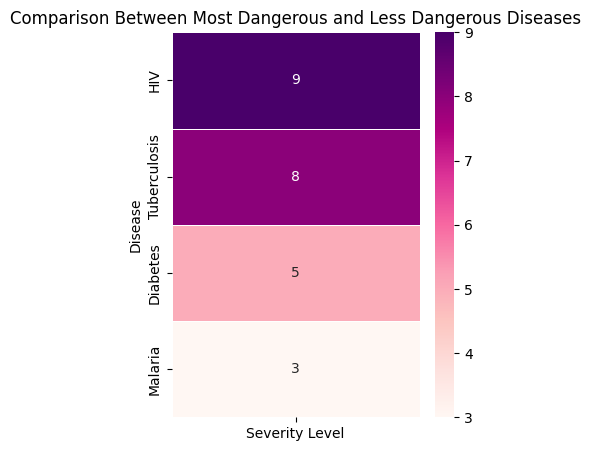

In [ ]:
# This heat map 


data = {
    "Disease": ["HIV", "Tuberculosis", "Diabetes", "Malaria"],
    "Severity Level": [9, 8, 5, 3]
}

df = pd.DataFrame(data)
df = df.set_index("Disease")

plt.figure(figsize=(4, 5))
sns.heatmap(df, annot=True, cmap="RdPu", linewidths=0.5)

plt.title("Comparison Between Most Dangerous and Less Dangerous Diseases")
plt.xlabel("")
plt.ylabel("Disease")
plt.show()

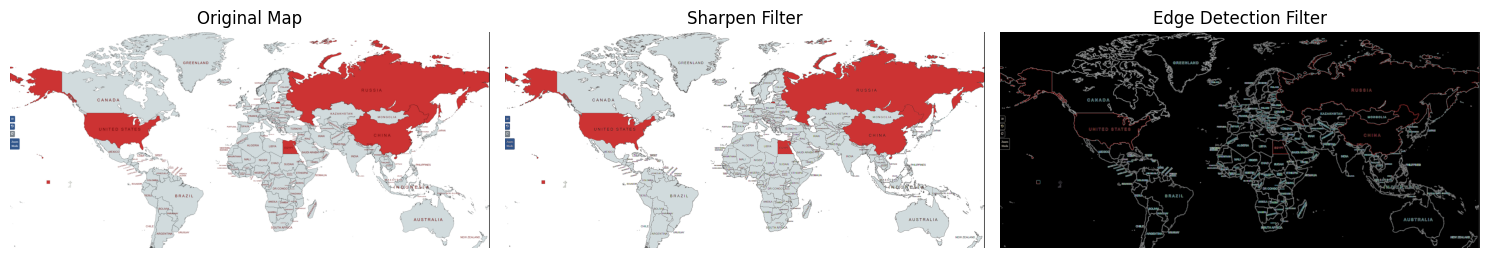

In [61]:
# Image Processing using Convolution Filters

img = cv2.imread("world_map.png")

if img is None:
    print("Image not found")
else:
    # تحويل من BGR إلى RGB
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


    sharpen_kernel = [
        [0, -1, 0],
        [-1, 5, -1],
        [0, -1, 0]
    ]

    edge_kernel = [
        [-1, -1, -1],
        [-1,  8, -1],
        [-1, -1, -1]
    ]
 
    sharpen_kernel = np.array(sharpen_kernel, dtype=np.float32)
    edge_kernel = np.array(edge_kernel, dtype=np.float32)

    sharpen_img = cv2.filter2D(img_rgb, -1, sharpen_kernel)
    edge_img = cv2.filter2D(img_rgb, -1, edge_kernel)


    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(img_rgb)
    plt.title("Original Map")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(sharpen_img)
    plt.title("Sharpen Filter")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(edge_img)
    plt.title("Edge Detection Filter")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

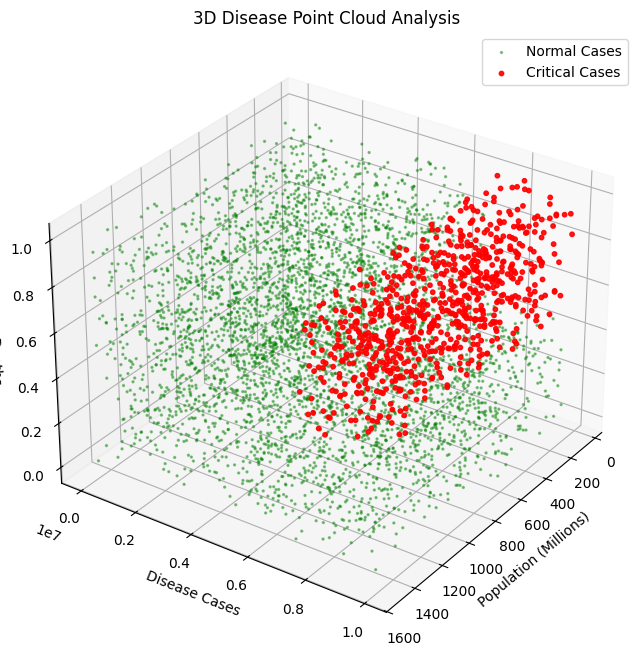

In [ ]:
# تحليل انتشار المرض بناء علي عدد السكان و الحالات و الوفيات 

n = 5000


population = np.random.uniform(50, 1500, n)      # عدد السكان بالمليون
cases = np.random.uniform(1000, 10000000, n)     # عدد الإصابات
deaths = np.random.uniform(100, 1000000, n)      # عدد الوفيات


critical_cases = 7000000
critical_deaths = 500000

# نقاط خطيرة وغير خطيرة
XN, YN, ZN = [], [], []
XL, YL, ZL = [], [], []


for i in range(n):

    # إذا كانت الإصابات والوفيات مرتفعة
    if cases[i] > critical_cases and deaths[i] > critical_deaths:

        # نقاط خطيرة
        XL.append(population[i])
        YL.append(cases[i])
        ZL.append(deaths[i])

    else:

        # نقاط عادية
        XN.append(population[i])
        YN.append(cases[i])
        ZN.append(deaths[i])


fig = plt.figure(figsize=(11, 8))
ax = fig.add_subplot(projection='3d')


ax.scatter(
    XN, YN, ZN,
    color='green',
    s=2,
    alpha=0.4,
    label='Normal Cases'
)

# 
ax.scatter(
    XL, YL, ZL,
    color='red',
    s=10,
    alpha=0.9,
    label='Critical Cases'
)


ax.set_xlabel('Population (Millions)')
ax.set_ylabel('Disease Cases')
ax.set_zlabel('Deaths')


ax.set_title("3D Disease Point Cloud Analysis")


ax.view_init(30, 35)


ax.legend()

plt.show()

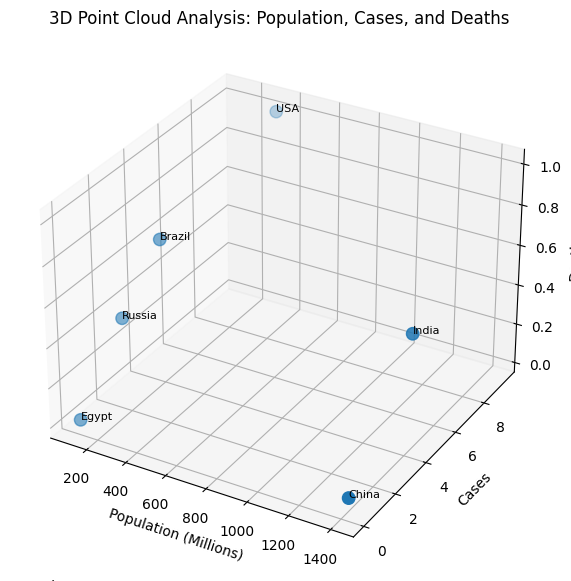

In [ ]:
# 3D Point Cloud Analysis: Population, Cases, and Deaths

data = {
    "Country": ["Egypt", "USA", "China", "Russia", "India", "Brazil"],
    "Population": [110, 331, 1412, 144, 1400, 214],   # بالمليون
    "Cases": [515000, 95000000, 3000000, 22000000, 44000000, 37000000],
    "Deaths": [22000, 1000000, 35000, 390000, 530000, 700000]
}

df = pd.DataFrame(data)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(df["Population"], df["Cases"], df["Deaths"], s=80)

for i in range(len(df)):
    ax.text(
        df["Population"][i], 
        df["Cases"][i],
        df["Deaths"][i], 
        df["Country"][i],  # Each point represents a country
        fontsize=8
    )

ax.set_xlabel("Population (Millions)") # X-axis
ax.set_ylabel("Cases") # Y-axis
ax.set_zlabel("Deaths")  # Z-axis
ax.set_title("3D Point Cloud Analysis: Population, Cases, and Deaths") 

plt.show()

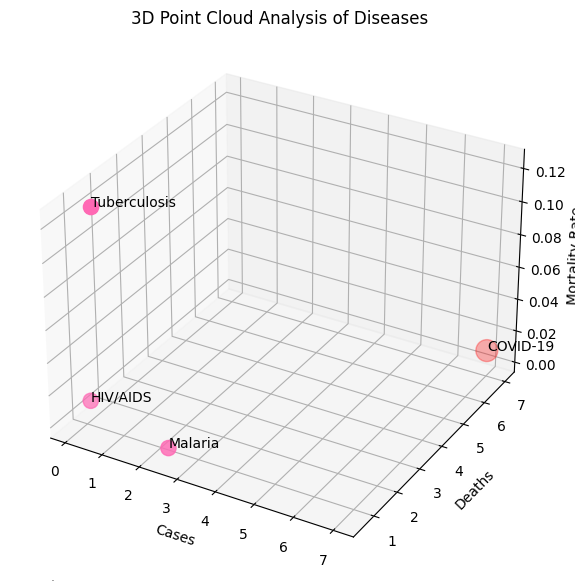

In [ ]:
# 3D Point Cloud : The most dangerous disease is highlighted in red

data = {
    "Disease": ["COVID-19", "HIV/AIDS", "Malaria", "Tuberculosis"],
    "Cases": [700000000, 39000000, 247000000, 10600000],
    "Deaths": [7000000, 630000, 608000, 1300000]
}

df = pd.DataFrame(data)

df["Mortality_Rate"] = df["Deaths"] / df["Cases"]    # حسب mortality rate

max_deaths = df["Deaths"].max() # نحدد أخطر مرض = أعلى وفيات

colors = []
sizes = []

for i in range(len(df)):
    if df["Deaths"][i] == max_deaths:   #لأحمر = أخطر مرض
        colors.append("red")
        sizes.append(250)
    else:
        colors.append("hotpink")      
        sizes.append(120)

fig = plt.figure(figsize=(10, 7))   # الحجم الأكبر = المرض الأخطر
ax = fig.add_subplot(projection='3d')

ax.scatter(df["Cases"], df["Deaths"], df["Mortality_Rate"], c=colors, s=sizes)

for i in range(len(df)):
    ax.text(
        df["Cases"][i],
        df["Deaths"][i],
        df["Mortality_Rate"][i],
        df["Disease"][i],
        fontsize=10
    )

ax.set_xlabel("Cases")
ax.set_ylabel("Deaths")
ax.set_zlabel("Mortality Rate")
ax.set_title("3D Point Cloud Analysis of Diseases")

plt.show()